In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2, norm
from scipy.interpolate import interp1d
from scipy.special import factorial
from scipy.integrate import quad
import os
import sys
sys.path.append('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release')
from Astrid.effective_area import bin_edges_to_centers, bin_centers_to_edges, apply_energy_smearing
import nuSIprop

import ultranest
import h5py
import corner



energy_bins = np.logspace(4, 7, 3*20+1)
energy_centers = bin_edges_to_centers(energy_bins)
energy_bins_low_resolution = np.logspace(4, 7, 20+1)
energy_centers_low_resolution = bin_edges_to_centers(energy_bins_low_resolution)

livetime12 = 12*365*24*3600

hese12_events_df = pd.read_csv('4_to_7_HESE12/20bins/hese12_20bins_df.csv', index_col=0)

background_df = pd.read_csv('4_to_7_HESE12/20bins/background_20bins_df.csv', index_col=0)
background_df.rename(columns={'background': 'events'}, inplace=True)

effective_area_df = pd.read_csv('4_to_7_HESE12/60bins/effective_area_4_to_7.csv', index_col=0)

energy_edges_MESE = [1.0, 2.15, 4.64, 10.0, 21.5, 46.4, 100.0, 215.4, 464.2, 1000.0, 2154.4, 4641.6, 10000.0, 100000.0]
energy_centers_MESE = [1.47, 3.16, 6.81, 14.7, 31.6, 68.1, 146.8, 316.2, 681.3, 1467.8, 3162.3, 6812.9, 31622.8]

energy_edges_MESE_BPL = [4.64, 10.0, 21.5, 46.4, 100.0, 215.4, 464.2, 1000.0, 2154.4, 4641.6, 10000.0]
energy_centers_MESE_BPL = [6.81, 14.7, 31.6, 68.1, 146.8, 316.2, 681.3, 1467.8, 3162.3, 6812.9]

#energy_edges_MESE = [4.64, 10.0, 21.5, 46.4, 100.0, 215.4, 464.2, 1000.0, 2154.4, 4641.6, 10000.0]
#energy_centers_MESE = [6.81, 14.7, 31.6, 68.1, 146.8, 316.2, 681.3, 1467.8, 3162.3, 6812.9]
energy_edges_MESE = np.asarray(energy_edges_MESE)
energy_centers_MESE = np.asarray(energy_centers_MESE)
energy_edges_MESE *= 1e3 # GeV
energy_centers_MESE *= 1e3 # GeV

norm_segmented = [0.0, 5.4, 3.9, 4.41, 5.51, 3.34, 1.55, 0.31, 0.59, 0.327, 0.0, 0.25, 0.0]
sigma_upper = [5.2, 5.8, 2.1, 0.93, 0.72, 0.63, 0.50, 0.33, 0.42, 0.32, 0.19, 0.24, 0.76]
sigma_lower = [0.0, 5.4, 2.0, 0.90, 0.66, 0.52, 0.35, 0.31, 0.23, 0.187, 0.0, 0.16, 0.0]

# physical pivot used by the paper (100 TeV). Convert to GeV. Observed y (E^2 phi) and asymmetric errors in the same units
E0 = 1e5    # if E in GeV; 100 TeV = 1e5 GeV
y_obs = np.asarray(norm_segmented) * 1e-18 * E0**2
sigma_upper = np.asarray(sigma_upper) * 1e-18 * E0**2
sigma_lower = np.asarray(sigma_lower) * 1e-18 * E0**2
sigma1 = 2 * sigma_upper * sigma_lower / (sigma_upper + sigma_lower)    # Acts as an 'average width'
sigma2 = (sigma_upper - sigma_lower) / (sigma_upper + sigma_lower)       # Encodes the asymmetry



def SPL_flux(norm=2.13, si=2.548, energies=energy_centers_MESE):
    # SPL model flux
    # Normalized at E = 100TeV
    # Best fit MESE: norm = 2.13^{0.18}_{-0.17}, si = 2.548^{0.039}_{-0.041}
    #si, norm = theta
    norm = norm*1e-18
    return  norm * (energies / E0)**(-si)
    
    
def BPL_flux(norm=2.28, si1=1.72, si2=2.839, E_break=10**4.524, energies=energy_centers_MESE):
    # BPL model flux
    # Normalized at E = 100TeV = 1e5 GeV
    # Best fit MESE: norm = 2.28, si1 = 1.72, si2 = 2.839, E_break = 10**(4.524) GeV
    norm = norm*1e-18
    if E_break > 1e5:
        norm_break  = norm * (E_break / E0)**(-si1)
    else:
        norm_break  = norm * (E_break / E0)**(-si2)
    
    # If used for integration within the bin, energies will be a single value.
    if isinstance(energies, float):
        if energies < E_break:
            flux = norm_break * (energies / E0)**(-si1)
        else:
            flux = norm_break * (energies / E0)**(-si2)
    else:
        flux = np.zeros(len(energies))
        for i, E in enumerate(energies):
            if E < E_break:
                flux[i] = norm_break * (E / E_break)**(-si1)
            else:
                flux[i] = norm_break * (E / E_break)**(-si2)
    return flux 


def LP_flux(norm=2.58, alpha=2.669, beta=0.359, energies=energy_centers_MESE):
    # Log Parabola model flux
    # Normalized at E = 100TeV
    # Best fit MESE: norm = 2.42, alpha = 2.05, beta = 2.54
    norm = norm*1e-18
    return  norm * (energies / E0)**(-alpha - beta * np.log10(energies / E0)) 


def integrate_model_E2phi(theta, bin_edges):
    #norm, si1, si2, E_break = theta

    y_bin_avg = []
    for i in range(len(bin_edges)-1):
        Emin, Emax = bin_edges[i], bin_edges[i+1]
        Es = np.logspace(np.log10(Emin), np.log10(Emax), 50)
        if len(theta) == 2:
            norm, si = theta
            vals = SPL_flux(norm, si, energies=Es) * Es**2
        elif len(theta) == 4:
            norm, si1, si2, E_break = theta
            E_break = 10**E_break
            vals = BPL_flux(norm, si1, si2, E_break, energies=Es) * Es**2
        elif len(theta) == 3:
            norm, alpha, beta = theta
            vals = LP_flux(norm, alpha, beta, energies=Es) * Es**2

        integral = np.trapz(vals, Es)
        avg = integral / (Emax - Emin)   # <-- critical
        y_bin_avg.append(avg)
    return np.array(y_bin_avg)


def loglike(theta):
    # Valid for all flux models
    y_pred = integrate_model_E2phi(theta, energy_edges_MESE)
    y_err = (sigma1 + sigma2 * (y_pred - y_obs)) * 0.5
    #print('y_err: ', y_err)
    if np.any(y_err <= 0):
        print('Zeros or negatives in y_err')
        y_err[y_err <= 0] = np.abs(y_err[y_err <= 0])
        obs = y_obs[y_err <= 0]
        pred = y_pred[y_err <= 0]
        y_obs[y_err <= 0] = pred
        y_pred[y_err <= 0] = obs
        
    ll = -0.5 * np.sum((y_obs - y_pred)**2 / y_err**2) #- np.sum(np.log(y_err))
    return ll

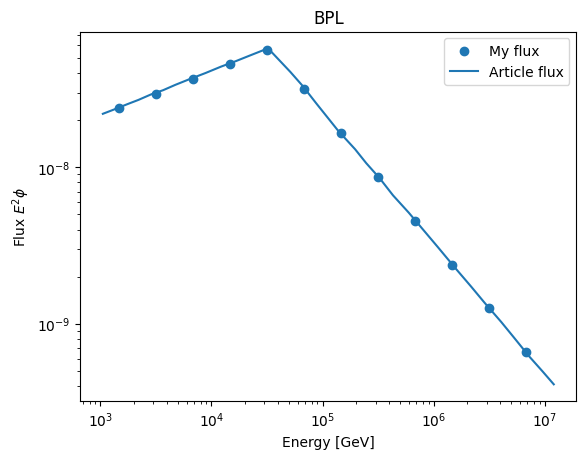

In [50]:
flux_BPL_MESE = pd.read_csv('BPL_MESE_bestfit.csv', header=None)


flux_test = BPL_flux()

plt.scatter(energy_centers_MESE[:-1], flux_test[:-1]*energy_centers_MESE[:-1]**2, label='My flux')
plt.plot(flux_BPL_MESE[0], flux_BPL_MESE[1], label='Article flux')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel("Flux $E^2 \phi $")
plt.title("BPL")
plt.legend()
plt.show()

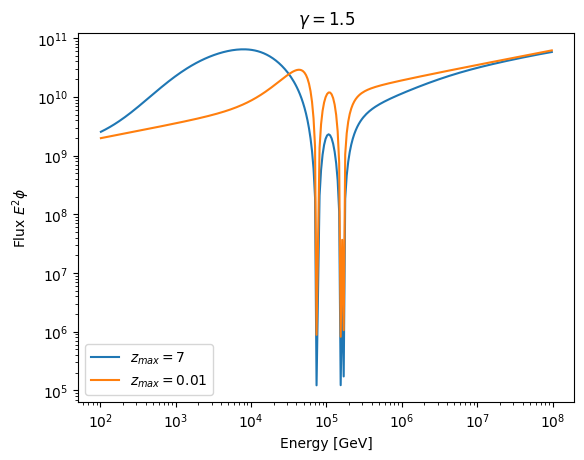

In [128]:
flux_spl_z7 = pd.read_csv("flux_test_z7.csv", header=0)
flux_total_spl_z7 = flux_spl_z7["nu_e"] + flux_spl_z7["nu_mu"] + flux_spl_z7["nu_tau"]
#flux_spl_small_g = pd.read_csv("flux_test_z7_g1e-1.csv", header=0)
#flux_total_spl_small_g = flux_spl_small_g["nu_e"] + flux_spl_small_g["nu_mu"] + flux_spl_small_g["nu_tau"]
flux_spl_z001 = pd.read_csv("flux_test_z001.csv", header=0)
flux_total_spl_z001 = flux_spl_z001["nu_e"] + flux_spl_z001["nu_mu"] + flux_spl_z001["nu_tau"]

#energy_z2 = flux_spl.index.values
#energy_z2 = np.array(energy_z2) / 1e9
#print(energy_z2)
energies = flux_spl["Energy"]
energies = np.array(energies) / 1e9
#print(energies)

energy_test = np.logspace(2, 7, 300)
#BPL_flux_test = BPL_flux(energy_test, E_break=10**4.8)

#plt.plot(energy_z001, 1e-18 * flux_total_z001 * energy_z001**2, label="nuSIprop, " + "$z_{max} = 0.01$")
#plt.plot(energy_z2, 1e-18 * flux_total_z2 * energy_z2**2, label="nuSIprop, " + "$z_{max} = 2$")
#plt.plot(energy_test, 8.5* BPL_flux_test * energy_test**2, label="BPL 'original'")
#plt.plot(energies,  flux_total_spl * energies**2, label="z=7")
plt.plot(energies,  flux_total_spl_z7 * energies**2, label="$z_{max}=7$")
plt.plot(energies,  flux_total_spl_z001 * energies**2, label="$z_{max}=0.01$")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel("Flux $E^2 \phi $")
plt.title(r'$\gamma=1.5$')

plt.legend()
plt.show()

In [3]:
import itertools
from dataclasses import dataclass
from typing import Callable, Dict, Iterable, Sequence

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from typing import Optional

@dataclass(frozen=True)
class ScanParam:
    name: Optional[str] = None
    values: Optional[Sequence[float]] = None
    label: Optional[str] = None
        
"""@dataclass(frozen=True)
class ScanParam:
    name: str
    values: Sequence[float]
    label: str | None = None"""


def run_profile_scan(
    loglike_fn: Callable[[Dict[str, float]], float],
    params: Sequence[ScanParam],
) -> tuple[Dict[str, np.ndarray], np.ndarray]:
    """
    Evaluates log-likelihood on the full Cartesian grid defined by params.

    Parameters
    ----------
    loglike_fn : callable
        Takes {param_name: value, ...} and returns log-likelihood.
    params : list[ScanParam]
        Each ScanParam supplies the grid to scan.

    Returns
    -------
    grid : dict[str, np.ndarray]
        Mapping from parameter name to numpy array of grid points.
    llh : np.ndarray
        N-D array with shape [len(p.values) for p in params].
    """
    grid = {p.name: np.asarray(p.values) for p in params}
    shape = tuple(len(p.values) for p in params)
    llh = np.empty(shape, dtype=float)

    for flat_idx, combo in enumerate(itertools.product(*grid.values())):
        idx = np.unravel_index(flat_idx, shape)
        point = dict(zip(grid.keys(), combo))
        llh[idx] = loglike_fn(point)
    return grid, llh



In [72]:
norm = np.linspace(1.1, 3.2, 20)
si1 = np.linspace(0.0, 3.0, 20)
si2 = np.linspace(2.4, 3.3, 20)
# Scan in log10(E_break) space for better visualization
log10_E_break = np.linspace(4, 5.0, 20)
param_names = ['norm', 'si1', 'si2', 'E_break']

def loglike_wrapper(point_dict):
    # Convert log10(E_break) back to E_break for the likelihood function
    point_dict_converted = point_dict.copy()
    """if 'E_break' in point_dict_converted:
        # E_break is in log10 space, convert to actual value
        point_dict_converted['E_break'] = 10**point_dict_converted['E_break']"""
    theta = [point_dict_converted[name] for name in param_names]
    return loglike(theta)   # your existing function

grid_BPL, llh_BPL = run_profile_scan(
    loglike_wrapper,
    [
        ScanParam('norm', norm),
        ScanParam('si1', si1),
        ScanParam('si2', si2),
        ScanParam('E_break', log10_E_break),  # Use log10 space
    ],
)

# SKA MAN PLOTTA  -2DELTA LLH MED -2(LLH_BPL - LLH_BPL_MAX) ISTÄLLET FÖR MED LLH_SPL?

LLH for SPL:  -56.98787449375113
BPL best parameters:  {'norm': 2.3157894736842106, 'si1': 1.7368421052631577, 'si2': 2.826315789473684, 'E_break': 4.526315789473684}
LLH for BPL:  -16.473592273504625


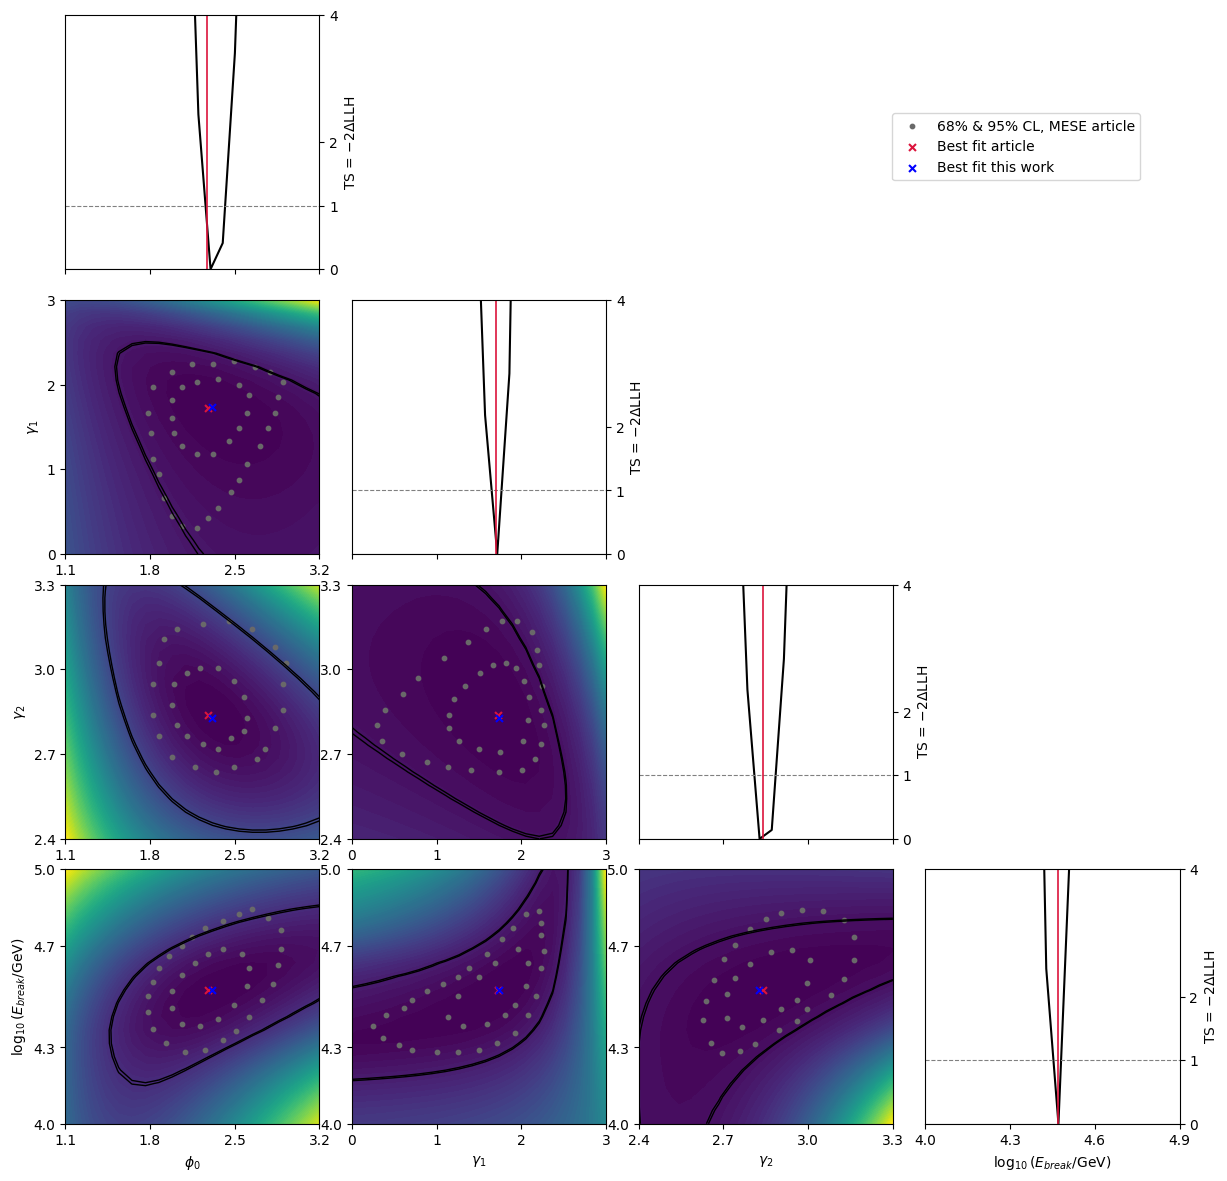

In [73]:
from typing import Optional

spl_flux = SPL_flux(norm=2.13, si=2.548)
llh_spl = loglike(theta=[2.13, 2.548])
print('LLH for SPL: ', llh_spl)
param_names = ['norm', 'si1', 'si2', 'E_break']

max_LLH_bpl = llh_BPL.max()
bpl_best_index = np.unravel_index(llh_BPL.argmax(), llh_BPL.shape)
bpl_best_parameters = {param_names[i]: grid_BPL[param_names[i]][bpl_best_index[i]] for i in range(len(param_names))}
print('BPL best parameters: ', bpl_best_parameters)
print('LLH for BPL: ', max_LLH_bpl)
#old_bpl_llh = loglike(theta=[2.28, 1.72, 2.839, 4.524])
#print('LLH for BPL (old): ', old_bpl_llh)

#TS = -2.0 * (max_LLH_bpl - llh_spl)
#print('TS for BPL: ', TS)
#outer_TS_at_4 = [[1.89, 0.80, 2.67, 4.34], [2.75, 2.17, 3.10, 4.75]]

def plot_profile_corner(
    param_grid: Dict[str, np.ndarray],
    llh_grid: np.ndarray,
    labels: Optional[Sequence[str]] = None,
    ref_point: Optional[Dict[str, float]] = None,
    contour_levels: Iterable[float] = (2.30, 5.99),   # 68% & 95% for 2 dof
    cmap: str = 'viridis',
    panel_size: float = 3.6,                          # inches per dimension
):
    names = list(param_grid.keys())
    ndim = len(names)
    if labels is None:
        labels = names

    #ts_grid = 2.0 * (np.min(llh_grid) - llh_grid)
    #ts_grid = 2.0 * (llh_spl - llh_grid) + np.max(llh_grid)
    best_index = np.unravel_index(llh_grid.argmax(), llh_grid.shape)
    best_parameters = {param_names[i]: param_grid[param_names[i]][best_index[i]] for i in range(len(param_names))}
    TS = -2.0 * (llh_BPL[best_index[0]][best_index[1]][best_index[2]][:] - llh_spl)


    """def profile(ts_array, keep_axes):
        axes = tuple(i for i in range(ts_array.ndim) if i not in keep_axes)
        return ts_array.max(axis=axes) if axes else ts_array"""

    fig = plt.figure(figsize=(panel_size * ndim, panel_size * ndim))
    gs = gridspec.GridSpec(ndim, ndim, wspace=0.12, hspace=0.12)

    for i, name_i in enumerate(names):
        xi = param_grid[name_i]
        ax = fig.add_subplot(gs[i, i])
        ax.set_box_aspect(1)                    # make diagonal panels square
        idx = tuple(best_index[j] if j != i else slice(None) for j in range(ndim))
        #ts_1d = -2.0 * (llh[idx] - llh_spl)
        ts_1d = -2.0 * (llh_BPL[idx] - np.max(llh_BPL))
        #ts_1d = profile(TS, (i,))
        ax.plot(xi, ts_1d, color='black')
        ax.axhline(0, color='gray', lw=0.8)
        ax.axhline(1, color='gray', lw=0.8, linestyle='--')
        #ax.axvline(outer_TS_at_4[0][i], color='crimson', linestyle='--') #Outer extent of TS at -2Delta LLH = 4 in original paper
        #ax.axvline(outer_TS_at_4[1][i], color='crimson', linestyle='--')
        yticks = np.asarray([0, 1, 2, 4])
        #ylabels = [f'\\${x:1.2f}' for x in yticks]
        ylabels = [str(x) for x in yticks]
        ax.set_yticks(yticks, labels=ylabels)
        xmin, xmax = ax.get_xlim()
        xticks = np.linspace(xmin, xmax, 4)
        ax.set_xticks(xticks)
        ax.set_xticklabels([])
        if i == 3:
            ax.set_xlabel(labels[i])
            ax.set_xticklabels([4.0, 4.3, 4.6, 4.9])
        ax.set_ylabel('TS = $-2\\Delta$LLH')
        ax.set_ylim(0, 4)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        if ref_point:
            ax.axvline(ref_point[name_i], color='crimson', lw=1.2)

        for j in range(i):
            name_j = names[j]
            xj = param_grid[name_j]
            ax = fig.add_subplot(gs[i, j])
            ax.set_box_aspect(1)                # square off-diagonal panels too
            #ts_2d = profile(ts_grid, (i, j))
            idx = tuple(slice(None) if k in (i, j) else best_index[k] for k in range(ndim))
            ts_2d = -2.0 * (llh_BPL[idx] - llh_spl)
            ts_2d = ts_2d.T      # because j < i, axes come out (j,i)
            cf = ax.contourf(
                xj, xi, ts_2d,
                levels=np.linspace(ts_2d.min(), ts_2d.max(), 80),
                cmap=cmap
            )
            ax.contour(xj, xi, ts_2d,
                       levels=contour_levels,
                       colors='k', linewidths=1.0)
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            xticks = np.linspace(xmin, xmax, 4)
            yticks = np.linspace(ymin, ymax, 4)
            ax.set_xticks(np.round(xticks, 2))
            ax.set_yticks(np.round(yticks, 1))
            
            if i == 3  and j == 0:
                norm_Ebreak = pd.read_csv('norm_Ebreak_MESE.csv', header=None)
                ax.scatter(norm_Ebreak[0], norm_Ebreak[1], color='dimgrey', s=10, label="68% & 95% CL, MESE article")
            elif i == 2 and j == 0:
                norm_si2 = pd.read_csv('norm_si2_MESE.csv', header=None)
                ax.scatter(norm_si2[0], norm_si2[1], color='dimgrey', s=10, label="68% & 95% CL, MESE article")
            elif i == 1 and j == 0:
                norm_si1 = pd.read_csv('norm_si1_MESE.csv', header=None)
                ax.scatter(norm_si1[0], norm_si1[1], color='dimgrey', s=10, label="68% & 95% CL, MESE article")
            elif i == 3 and j == 1:
                si1_Ebreak = pd.read_csv('si1_Ebreak_MESE.csv', header=None)
                ax.scatter(si1_Ebreak[0], si1_Ebreak[1], color='dimgrey', s=10, label="68% & 95% CL, MESE article")
            elif i == 2 and j == 1:
                si1_si2 = pd.read_csv('si1_si2_MESE.csv', header=None)
                ax.scatter(si1_si2[0], si1_si2[1], color='dimgrey', s=10, label="68% & 95% CL, MESE article")
            elif i == 3 and j == 2:
                si2_Ebreak = pd.read_csv('si2_Ebreak_MESE.csv', header=None)
                ax.scatter(si2_Ebreak[0], si2_Ebreak[1], color='dimgrey', s=10, label="68% & 95% CL, MESE article")
                
                
            if ref_point:
                if j == 2:
                    label1 = 'Best fit article'
                    label2 = 'Best fit this work'
                else:
                    label1 = None
                    label2 = None
                    
                ax.scatter(ref_point[name_j], ref_point[name_i],
                           color='crimson', s=25, marker='x', label=label1)
                ax.scatter(best_parameters[name_j], best_parameters[name_i],
                           color='blue', s=25, marker='x', label=label2)
            ax.set_xlabel(labels[j])
            
            if j == 0:
                ax.set_ylabel(labels[i])
                
            elif j == 2:
                ax.legend(loc='upper right', bbox_to_anchor=(2.0, 4.0))

    return fig

#grid['E_break'] = E_break
#print(grid['E_break'])
fig = plot_profile_corner(
    param_grid=grid_BPL,
    llh_grid=llh_BPL,
    labels=[r'$\phi_0$', r'$\gamma_1$', r'$\gamma_2$', r'$\log_{10}(E_{break}/\mathrm{GeV})$'],
    ref_point={'norm': 2.28, 'si1': 1.72, 'si2': 2.839, 'E_break': 4.524},
    contour_levels=(2.279, 5.991)
)


# Om TS involverar max(LLH_BPL) så är dof = 4. Annars om jämför med max(LLH_SPL) så är dof = 2
# contour_levels = (2.279, 5.991)


In [33]:
norm = np.linspace(1.50, 3.50, 20)
alpha = np.linspace(2.20, 3.20, 20)
beta = np.linspace(0.00, 1.00, 20)
param_names = ['norm', 'alpha', 'beta']

def loglike_wrapper(point_dict):
    # Convert log10(E_break) back to E_break for the likelihood function
    point_dict_converted = point_dict.copy()
    """if 'E_break' in point_dict_converted:
        # E_break is in log10 space, convert to actual value
        point_dict_converted['E_break'] = 10**point_dict_converted['E_break']"""
    theta = [point_dict_converted[name] for name in param_names]
    return loglike(theta)   # your existing function

grid_LP, llh_LP = run_profile_scan(
    loglike_wrapper,
    [
        ScanParam('norm', norm),
        ScanParam('alpha', alpha),
        ScanParam('beta', beta),
    ],
)

LLH for SPL:  -14.246882980631383
LP best parameters:  {'norm': 2.6578947368421053, 'alpha': 2.673684210526316, 'beta': 0.3684210526315789}
LLH for LP:  -7.66309407758097
LLH for LP (old):  -7.72654645063774
TS for LP:  -13.167577806100827


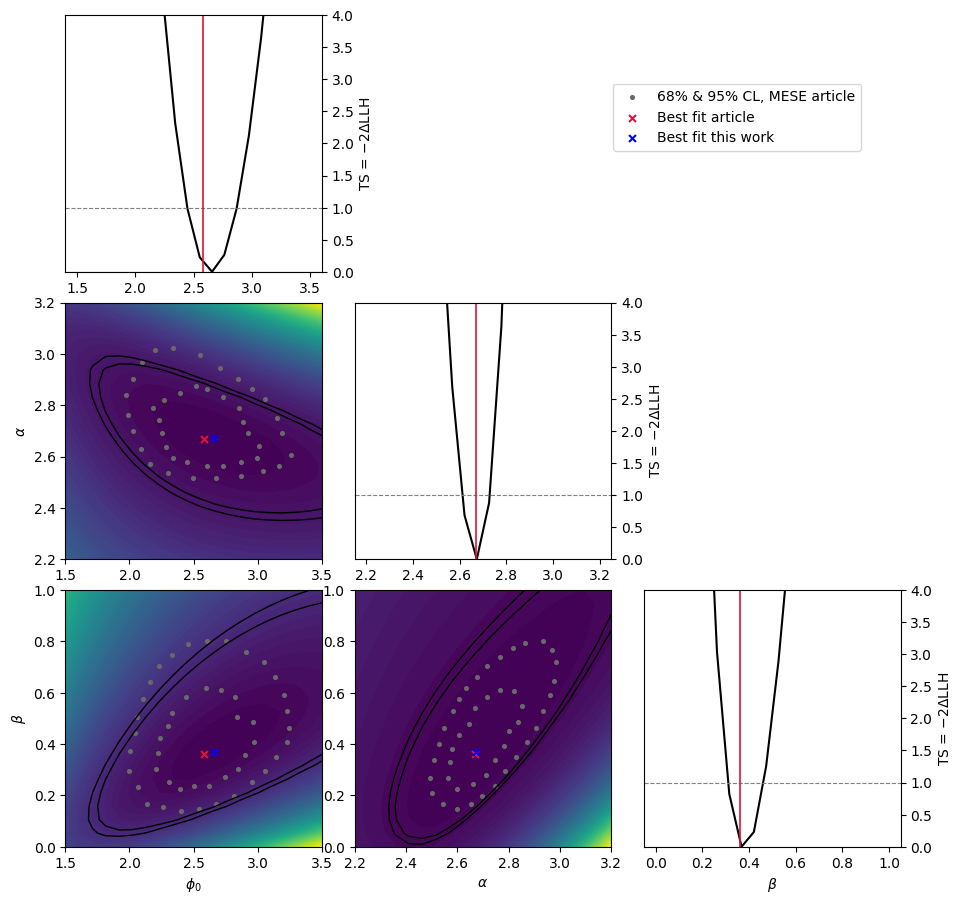

In [ ]:
from typing import Optional
param_names = ['norm', 'alpha', 'beta']

spl_flux = SPL_flux(norm=2.13, si=2.548)
#llh_spl = loglike(theta=[2.13, 2.548])
#print('LLH for SPL: ', llh_spl)

max_LLH_lp = llh_LP.max()
lp_best_index = np.unravel_index(llh_LP.argmax(), llh_LP.shape)
lp_best_parameters = {param_names[i]: grid_LP[param_names[i]][lp_best_index[i]] for i in range(len(param_names))}
print('LP best parameters: ', lp_best_parameters)
print('LLH for LP: ', max_LLH_lp)
#old_lp_llh = loglike(theta=[2.58, 2.67, 0.36])
#print('LLH for LP (old): ', old_lp_llh)

#TS = -2.0 * (max_LLH_lp - llh_spl)
#print('TS for LP: ', TS)

#outer_TS_at_4 = [[2.17, 2.54, 0.176], [3.09, 2.9, 0.696]]

def plot_profile_corner(
    param_grid: Dict[str, np.ndarray],
    llh_grid: np.ndarray,
    labels: Optional[Sequence[str]] = None,
    ref_point: Optional[Dict[str, float]] = None,
    contour_levels: Iterable[float] = (2.30, 5.99),   # 68% & 95% for 2 dof
    cmap: str = 'viridis',
    panel_size: float = 3.6,                          # inches per dimension
):
    names = list(param_grid.keys())
    ndim = len(names)
    if labels is None:
        labels = names

    #ts_grid = 2.0 * (np.min(llh_grid) - llh_grid)
    #ts_grid = 2.0 * (llh_spl - llh_grid) + np.max(llh_grid)
    best_index = np.unravel_index(llh_grid.argmax(), llh_grid.shape)
    best_parameters = {param_names[i]: param_grid[param_names[i]][best_index[i]] for i in range(len(param_names))}
    #TS = -2.0 * (llh[best_index[0]][best_index[1]][best_index[2]][:] - llh_spl)


    """def profile(ts_array, keep_axes):
        axes = tuple(i for i in range(ts_array.ndim) if i not in keep_axes)
        return ts_array.max(axis=axes) if axes else ts_array"""

    fig = plt.figure(figsize=(panel_size * ndim, panel_size * ndim))
    gs = gridspec.GridSpec(ndim, ndim, wspace=0.12, hspace=0.12)

    for i, name_i in enumerate(names):
        xi = param_grid[name_i]
        ax = fig.add_subplot(gs[i, i])
        ax.set_box_aspect(1)                    # make diagonal panels square
        idx = tuple(best_index[j] if j != i else slice(None) for j in range(ndim))
        #ts_1d = -2.0 * (llh[idx] - llh_spl)
        ts_1d = -2.0 * (llh_LP[idx] - np.max(llh_LP))
        #ts_1d = profile(TS, (i,))
        ax.plot(xi, ts_1d, color='black')
        ax.axhline(0, color='gray', lw=0.8)
        ax.axhline(1, color='gray', lw=0.8, linestyle='--')
        #ax.axvline(outer_TS_at_4[0][i], color='crimson', linestyle='--', label='Parameter value at TS=4 in article') #Outer extent of TS at -2Delta LLH = 4 in original paper
        #ax.axvline(outer_TS_at_4[1][i], color='crimson', linestyle='--')
        yticks = np.asarray([0, 1, 2, 4])
        ylabels = [str(x) for x in yticks]
        ax.set_yticks(yticks, labels=ylabels)
        xmin, xmax = ax.get_xlim()
        xticks = np.linspace(xmin, xmax, 4)
        ax.set_xticks(xticks)
        ax.set_xticklabels([])
        if i == 2:
            ax.set_xlabel(labels[i])
            ax.set_xticklabels([0.00, 0.33, 0.67, 1.00])
        ax.set_ylabel('TS = $-2\\Delta$LLH')
        ax.set_ylim(0, 4)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        if ref_point:
            ax.axvline(ref_point[name_i], color='crimson', lw=1.2)

        for j in range(i):
            name_j = names[j]
            xj = param_grid[name_j]
            ax = fig.add_subplot(gs[i, j])
            ax.set_box_aspect(1)                # square off-diagonal panels too
            #ts_2d = profile(ts_grid, (i, j))
            idx = tuple(slice(None) if k in (i, j) else best_index[k] for k in range(ndim))
            ts_2d = -2.0 * (llh_LP[idx] - np.max(llh_LP))
            ts_2d = ts_2d.T      # because j < i, axes come out (j,i)
            cf = ax.contourf(
                xj, xi, ts_2d,
                levels=np.linspace(ts_2d.min(), ts_2d.max(), 80),
                cmap=cmap
            )
            ax.contour(xj, xi, ts_2d,
                       levels=contour_levels,
                       colors='k', linewidths=1.0)
                        xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            xticks = np.linspace(xmin, xmax, 4)
            yticks = np.linspace(ymin, ymax, 4)
            ax.set_xticks(xticks)
            ax.set_yticks(yticks)
            
            if i == 2  and j == 0:
                norm_beta = pd.read_csv('norm_beta_MESE.csv', header=None)
                ax.scatter(norm_beta[0], norm_beta[1], color='dimgrey', s=7, label="68% & 95% CL, MESE article")
            if i == 2 and j == 1:
                alpha_beta = pd.read_csv('alpha_beta_MESE.csv', header=None)
                ax.scatter(alpha_beta[0], alpha_beta[1], color='dimgrey', s=7, label="68% & 95% CL, MESE article")
            if i == 1 and j == 0:
                norm_alpha = pd.read_csv('norm_alpha_MESE.csv', header=None)
                ax.scatter(norm_alpha[0], norm_alpha[1], color='dimgrey', s=7, label="68% & 95% CL, MESE article")

                
            if ref_point:
                if j == 1:
                    label1 = 'Best fit article'
                    label2 = 'Best fit this work'
                else:
                    label1 = None
                    label2 = None
                    
                ax.scatter(ref_point[name_j], ref_point[name_i],
                           color='crimson', s=25, marker='x', label=label1)
                ax.scatter(best_parameters[name_j], best_parameters[name_i],
                           color='blue', s=25, marker='x', label=label2)
            ax.set_xlabel(labels[j])
            
            if j == 0:
                ax.set_ylabel(labels[i])
            elif j == 1:
                ax.legend(loc='upper right', bbox_to_anchor=(2.0, 3.0))
    return fig


fig = plot_profile_corner(
    param_grid=grid_LP,
    llh_grid=llh_LP,
    labels=[r'$\phi_0$', r'$\alpha$', r'$\beta$'],
    ref_point={'norm': 2.58, 'alpha': 2.67, 'beta': 0.36},
    contour_levels=(0.9889, 3.841)
)

# Om TS involverar max(LLH_LP) så är dof = 3. Annars om jämför med max(LLH_SPL) så är dof = 2

In [91]:
norm = np.linspace(1.50, 3.50, 20)
si = np.linspace(1.80, 3.20, 20)
param_names = ['norm', 'si']

def loglike_wrapper(point_dict):
    # Convert log10(E_break) back to E_break for the likelihood function
    point_dict_converted = point_dict.copy()
    """if 'E_break' in point_dict_converted:
        # E_break is in log10 space, convert to actual value
        point_dict_converted['E_break'] = 10**point_dict_converted['E_break']"""
    theta = [point_dict_converted[name] for name in param_names]
    return loglike(theta)   # your existing function

grid, llh = run_profile_scan(
    loglike_wrapper,
    [
        ScanParam('norm', norm),
        ScanParam('si', si),
    ],
)

In [94]:
spl_flux = SPL_flux(norm=2.13, si=2.548)
llh_spl_paper = loglike(theta=[2.13, 2.548])
print('LLH for SPL (paper): ', llh_spl_paper)

max_LLH_spl = llh.max()
spl_best_index = np.unravel_index(llh.argmax(), llh.shape)
spl_best_parameters = {param_names[i]: grid[param_names[i]][spl_best_index[i]] for i in range(len(param_names))}
print('SPL best parameters (this work): ', spl_best_parameters)
print('LLH for SPL (this work): ', max_LLH_spl)

TS_LP = -2* (-7.66309407758097 - max_LLH_spl)
print('TS for LP (this work): ', TS_LP)

TS_LP_paper = -2* (-7.72654645063774 - llh_spl_paper)
print('TS for LP (best fit values from paper, TS method this work): ', TS_LP_paper)


TS_BPL = -2*(-4.077644696672701 - max_LLH_spl)
print('TS for BPL (this work): ', TS_BPL)


LLH for SPL (paper):  -14.246882980631383
SPL best parameters (this work):  {'norm': 2.1315789473684212, 'si': 2.5368421052631582}
LLH for SPL (this work):  -14.049373155509368
TS for LP (this work):  -12.772558155856796
TS for LP (best fit values from paper, TS method this work):  -13.040673059987286
TS for BPL (this work):  -19.943456917673334
